# Demo Notebook (Standalone Viva)

This notebook is a standalone copy of the viva demo workflow from the end of DL23, adapted to run independently from the `06_demo` folder.

What it does end-to-end:
1. Installs missing dependencies.
2. Imports all required libraries.
3. Loads base model + adapter from `06_demo/Models`.
4. Loads meaningful prompts from `06_demo/sample_inputs.txt`.
5. Runs deterministic inference and reports latency + outputs.

In [13]:
# Step 1: install required libraries (safe to rerun).
import importlib.util
import subprocess
import sys

required = {
    "torch": "torch",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "transformers": "transformers",
    "peft": "peft",
    "bitsandbytes": "bitsandbytes",
    "accelerate": "accelerate",
    "huggingface_hub": "huggingface_hub",
    "ipykernel": "ipykernel",
}

missing = [pkg for module, pkg in required.items() if importlib.util.find_spec(module) is None]

if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
else:
    print("All required packages are already installed.")

All required packages are already installed.


In [14]:
# Step 2: import libraries and resolve local demo paths.
import os
import re
import sys
import time
from pathlib import Path

import pandas as pd
import torch
from IPython.display import display
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

def _resolve_demo_root():
    # Search current and parent locations so this notebook can run from different working directories.
    candidates = [
        Path.cwd(),
        Path.cwd() / "06_demo",
        Path.cwd().parent / "06_demo",
        Path.cwd().parent.parent / "06_demo",
    ]
    for c in candidates:
        if (c / "sample_inputs.txt").exists() and (c / "Models").exists():
            return c.resolve()
    raise FileNotFoundError(
        "Could not locate demo root. Expected sample_inputs.txt and Models/ in 06_demo."
    )

DEMO_ROOT = _resolve_demo_root()
MODELS_DIR = DEMO_ROOT / "Models"
SAMPLE_INPUTS_PATH = DEMO_ROOT / "sample_inputs.txt"
BASE_MODEL_DIR = MODELS_DIR / "Qwen2.5-1.5B-Instruct"
ADAPTER_DIR = MODELS_DIR / "phase8_adapter_grpo_pilot"
EXPECTED_VENV = DEMO_ROOT / ".venv_demo"

print(f"Demo root: {DEMO_ROOT}")
print(f"Sample inputs: {SAMPLE_INPUTS_PATH}")
print(f"Base model path: {BASE_MODEL_DIR}")
print(f"Adapter path: {ADAPTER_DIR}")
print(f"Python executable: {sys.executable}")

# Friendly runtime warning if a demo-specific venv exists but the active kernel is not from that venv.
if EXPECTED_VENV.exists():
    active_python = Path(sys.executable).resolve()
    if str(EXPECTED_VENV.resolve()) not in str(active_python):
        print(
            "Warning: .venv_demo exists but this kernel is not using it. "
            "For full isolation, switch to the demo venv kernel."
        )

Demo root: /home/priyankajain/cropland1020/modis_data_final/06_demo
Sample inputs: /home/priyankajain/cropland1020/modis_data_final/06_demo/sample_inputs.txt
Base model path: /home/priyankajain/cropland1020/modis_data_final/06_demo/Models/Qwen2.5-1.5B-Instruct
Adapter path: /home/priyankajain/cropland1020/modis_data_final/06_demo/Models/phase8_adapter_grpo_pilot
Python executable: /home/priyankajain/cropland1020/modis_data_final/.venv/bin/python


## Viva Demo: Fast Comparative Inference

What this demo does:
1. Loads the quantized base model and Phase 8 adapter from the local `Models` folder.
2. Loads an unquantized base model with the same adapter for fair comparison.
3. Runs prompts from `sample_inputs.txt` on both variants.
4. Reports latency, token count, parsed predictions, and accuracy.

- Small prompt set and capped generation length keep runtime practical.
- Side-by-side outputs make quantization trade-offs easy to explain in viva.

In [15]:
# Step 3: load model artifacts from Models/ for comparative inference.
# We load two variants with the same adapter:
# 1) 4-bit quantized model
# 2) unquantized model
from huggingface_hub import snapshot_download

BASE_MODEL_REPO_ID = "Qwen/Qwen2.5-1.5B-Instruct"

def _missing_or_broken(path: Path) -> bool:
    if not path.exists():
        return True
    try:
        if path.is_symlink() and not path.resolve().exists():
            return True
    except OSError:
        return True
    return False

if _missing_or_broken(BASE_MODEL_DIR):
    print(
        f"Base model path is missing or broken: {BASE_MODEL_DIR}\n"
        f"Downloading {BASE_MODEL_REPO_ID} into Models/..."
    )
    BASE_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    try:
        snapshot_download(
            repo_id=BASE_MODEL_REPO_ID,
            local_dir=str(BASE_MODEL_DIR),
            local_dir_use_symlinks=False,
            resume_download=True,
        )
    except Exception as exc:
        raise RuntimeError(
            "Could not download the base model to 06_demo/Models. "
            "Check internet access and Hugging Face authentication, then retry."
        ) from exc

if not ADAPTER_DIR.exists():
    raise FileNotFoundError(
        f"Adapter directory not found: {ADAPTER_DIR}. "
        "Expected phase8_adapter_grpo_pilot inside 06_demo/Models."
    )

demo_tokenizer = AutoTokenizer.from_pretrained(
    str(BASE_MODEL_DIR), trust_remote_code=True, use_fast=True, local_files_only=True
)
if demo_tokenizer.pad_token is None:
    demo_tokenizer.pad_token = demo_tokenizer.eos_token

gpu_pref_dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

def _load_quantized_with_adapter():
    if torch.cuda.is_available():
        quant_cfg = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=gpu_pref_dtype,
        )
        base = AutoModelForCausalLM.from_pretrained(
            str(BASE_MODEL_DIR),
            quantization_config=quant_cfg,
            device_map="auto",
            trust_remote_code=True,
            local_files_only=True,
        )
    else:
        base = AutoModelForCausalLM.from_pretrained(
            str(BASE_MODEL_DIR),
            device_map="cpu",
            trust_remote_code=True,
            local_files_only=True,
        )

    model = PeftModel.from_pretrained(base, str(ADAPTER_DIR))
    model.eval()
    return model

def _load_unquantized_with_adapter():
    if torch.cuda.is_available():
        try:
            base = AutoModelForCausalLM.from_pretrained(
                str(BASE_MODEL_DIR),
                torch_dtype=gpu_pref_dtype,
                device_map="auto",
                trust_remote_code=True,
                local_files_only=True,
            )
        except Exception as exc:
            print(f"Warning: GPU unquantized load failed ({exc}). Falling back to CPU.")
            base = AutoModelForCausalLM.from_pretrained(
                str(BASE_MODEL_DIR),
                device_map="cpu",
                trust_remote_code=True,
                local_files_only=True,
            )
    else:
        base = AutoModelForCausalLM.from_pretrained(
            str(BASE_MODEL_DIR),
            device_map="cpu",
            trust_remote_code=True,
            local_files_only=True,
        )

    model = PeftModel.from_pretrained(base, str(ADAPTER_DIR))
    model.eval()
    return model

demo_model_quantized = _load_quantized_with_adapter()
demo_device_quantized = next(demo_model_quantized.parameters()).device

demo_model_unquantized = _load_unquantized_with_adapter()
demo_device_unquantized = next(demo_model_unquantized.parameters()).device

print("Comparative models ready.")
print(f"Quantized device: {demo_device_quantized}")
print(f"Unquantized device: {demo_device_unquantized}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

`torch_dtype` is deprecated! Use `dtype` instead!


Comparative models ready.
Quantized device: cuda:0
Unquantized device: cuda:0
GPU: NVIDIA H100 NVL


### Demo Step: Comparative Inference (Quantized vs Unquantized)

This section runs **all prompts** from `sample_inputs.txt` through two models:
1. **Quantized model**: 4-bit NF4 base + Phase 8 adapter.
2. **Unquantized model**: full-precision base + the same Phase 8 adapter.

Why this matters for viva analysis:
- Quantization can improve memory/speed but may damage reasoning stability.
- Typical failure modes include **infinite/degenerate looping** and **loss of reasoning track** before final answer.
- A side-by-side run helps show trade-offs in latency vs. answer quality.

Reported per prompt for both models:
1. End-to-end latency (seconds).
2. Number of generated tokens.
3. Parsed prediction (numeric for GSM8K-style, letter for GPQA).
4. Correctness against a built-in answer key for this demo set.

At the end, the cell prints a comparison table and plots accuracy (overall and task-wise).

Loaded 10 demo prompt(s) from: /home/priyankajain/cropland1020/modis_data_final/06_demo/sample_inputs.txt
Prompt 1 [GSM8K]: A shop had 48 pens. It sold 19 in the morning and 11 in the evening. How many are left?
Quantized -> pred: 20 | correct: False | latency: 4.47s | tokens: 80
Unquantized -> pred: 11 | correct: False | latency: 3.31s | tokens: 80
Prompt 2 [GSM8K]: If 3x + 5 = 20, what is x?
Quantized -> pred: 5 | correct: True | latency: 4.48s | tokens: 80
Unquantized -> pred: 3 | correct: False | latency: 3.3s | tokens: 80
Prompt 3 [GSM8K]: A student studies 45 minutes each day for 6 days. What is the total study time in hours?
Quantized -> pred: 6 | correct: False | latency: 4.49s | tokens: 80
Unquantized -> pred: 4 | correct: False | latency: 3.3s | tokens: 80
Prompt 4 [GSM8K]: A taxi fare is 80 rupees plus 12 rupees per km. What is the fare for 5 km?
Quantized -> pred: 1 | correct: False | latency: 4.47s | tokens: 80
Unquantized -> pred: 5 | correct: False | latency: 3.3s | toke

,prompt_id,task,question,gold,quantized_prediction,unquantized_prediction,quantized_correct,unquantized_correct,quantized_latency_sec,unquantized_latency_sec
0,1,gsm8k,A shop had 48 pens. It sold 19 in the morning ...,18,20,11,False,False,4.47,3.31
1,2,gsm8k,"If 3x + 5 = 20, what is x?",5,5,3,True,False,4.48,3.30
2,3,gsm8k,A student studies 45 minutes each day for 6 da...,4.5,6,4,False,False,4.49,3.30
3,4,gsm8k,A taxi fare is 80 rupees plus 12 rupees per km...,140,1,5,False,False,4.47,3.30
4,5,gsm8k,A rectangle has length 9 and width 4. What is ...,36,36,36,True,True,4.47,3.30
5,6,gpqa,[GPQA] Question: Two quantum states with energ...,B,None,None,False,False,4.50,3.32
6,7,gpqa,[GPQA] Question: trans-cinnamaldehyde was trea...,B,None,A,False,False,4.50,3.31
7,8,gpqa,[GPQA] Question: A spin-half particle is in a ...,D,A,A,False,False,4.51,3.32
8,9,gpqa,[GPQA] Question: In a parallel universe where ...,B,A,A,False,False,4.50,3.31
9,10,gpqa,[GPQA] Question: Calculate the eigenvector of ...,B,None,A,False,False,4.50,3.32



Overall accuracy (known-label prompts only):
Quantized model accuracy:   20.00%
Unquantized model accuracy: 10.00%


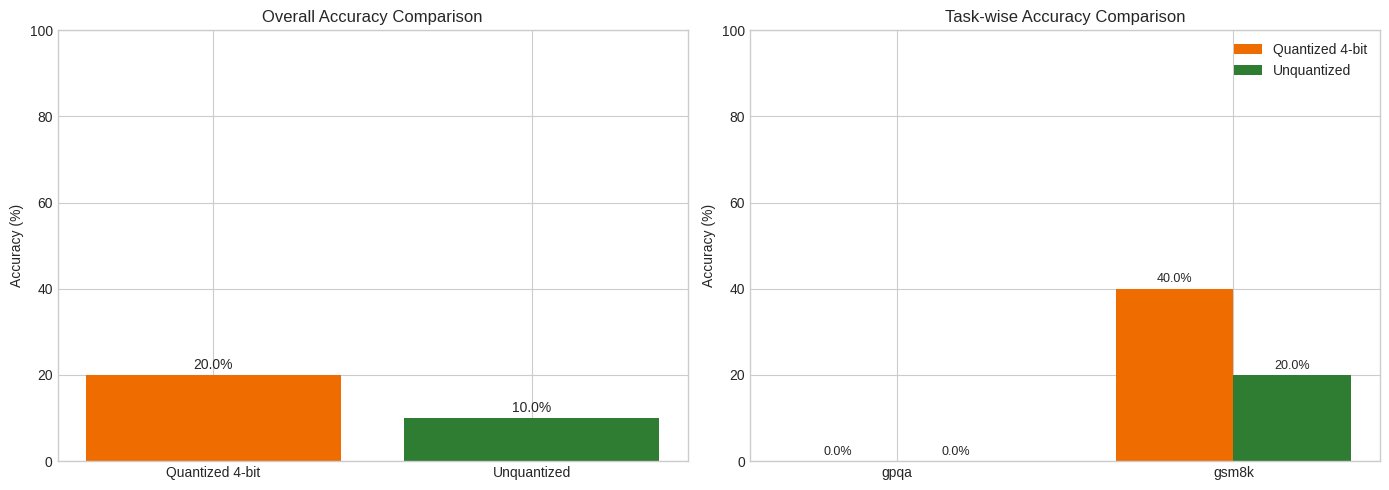

In [16]:
# Step 4: comparative inference on all demo prompts (quantized vs unquantized).
import matplotlib.pyplot as plt

def _load_demo_prompts(path, max_items=None):
    fallback_prompts = [
        "A shop had 48 pens. It sold 19 in the morning and 11 in the evening. How many are left?",
        "If 3x + 5 = 20, what is x?",
        "A student studies 45 minutes each day for 6 days. What is the total study time in hours?",
    ]
    if not os.path.exists(path):
        print(f"Warning: {path} not found. Using fallback prompts.")
        return fallback_prompts if max_items is None else fallback_prompts[:max_items]

    prompts = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            s = re.sub(r"^\d+\.\s*", "", s)
            prompts.append(s)

    if not prompts:
        print(f"Warning: {path} has no usable prompts. Using fallback prompts.")
        return fallback_prompts if max_items is None else fallback_prompts[:max_items]

    return prompts if max_items is None else prompts[:max_items]

DEMO_PROMPTS = _load_demo_prompts(str(SAMPLE_INPUTS_PATH), max_items=None)
print(f"Loaded {len(DEMO_PROMPTS)} demo prompt(s) from: {SAMPLE_INPUTS_PATH}")

def _extract_think_and_answer(text):
    clean = str(text).strip()
    if "</think>" in clean:
        left, right = clean.split("</think>", 1)
        think = left.replace("<think>", "").strip()
        answer = right.strip()
    else:
        think = ""
        answer = clean
    return think, answer

def _extract_last_number(text):
    matches = re.findall(r"-?\d+(?:\.\d+)?", str(text).replace(",", ""))
    if not matches:
        return None
    raw = matches[-1]
    try:
        num = float(raw)
        return int(num) if num.is_integer() else num
    except Exception:
        return raw

def _extract_choice_letter(text):
    m = re.search(r"\\boxed\{\s*([A-D])\s*\}", str(text), flags=re.IGNORECASE)
    if m:
        return m.group(1).upper()
    m = re.search(r"\b([A-D])\b", str(text), flags=re.IGNORECASE)
    if m:
        return m.group(1).upper()
    return None

def _task_and_gold(prompt_text):
    p = str(prompt_text)
    p_low = p.lower()

    # GSM8K-style prompts (numeric)
    if "shop had 48 pens" in p_low:
        return "gsm8k", 18
    if "3x + 5 = 20" in p:
        return "gsm8k", 5
    if "45 minutes each day for 6 days" in p_low:
        return "gsm8k", 4.5
    if "80 rupees plus 12 rupees per km" in p_low:
        return "gsm8k", 140
    if "rectangle has length 9 and width 4" in p_low:
        return "gsm8k", 36

    # GPQA prompts (multiple-choice letter)
    if "two quantum states with energies e1 and e2" in p_low:
        return "gpqa", "B"
    if "trans-cinnamaldehyde was treated with methylmagnesium bromide" in p_low:
        return "gpqa", "B"
    if "spin-half particle is in a linear superposition" in p_low:
        return "gpqa", "D"
    if "parallel universe where a magnet can have an isolated north or south pole" in p_low:
        return "gpqa", "B"
    if "calculate the eigenvector of a quantum mechanical operator" in p_low:
        return "gpqa", "B"

    return "unknown", None

def _compute_correctness(prompt_text, answer_text, raw_text):
    task, gold = _task_and_gold(prompt_text)
    if gold is None:
        return task, gold, None, None

    if task == "gsm8k":
        pred = _extract_last_number(answer_text)
        if pred is None:
            pred = _extract_last_number(raw_text)
        if pred is None:
            return task, gold, None, False
        try:
            is_correct = abs(float(pred) - float(gold)) < 1e-9
        except Exception:
            is_correct = str(pred).strip() == str(gold).strip()
        return task, gold, pred, is_correct

    if task == "gpqa":
        pred = _extract_choice_letter(answer_text)
        if pred is None:
            pred = _extract_choice_letter(raw_text)
        is_correct = (pred == str(gold).upper()) if pred is not None else False
        return task, gold, pred, is_correct

    return task, gold, None, None

def run_demo_inference(model, device, question, model_name, max_new_tokens=80):
    clean_question = re.sub(r"^\[(?:GPQA|MATH)\]\s*", "", str(question)).strip()
    prompt = (
        "You are a reasoning assistant. "
        "First reason inside <think>...</think>, then provide a concise final answer.\n\n"
        f"Question: {clean_question}\n<think>\n"
    )
    inputs = demo_tokenizer([prompt], return_tensors="pt").to(device)

    t0 = time.perf_counter()
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=demo_tokenizer.eos_token_id,
            eos_token_id=demo_tokenizer.eos_token_id,
        )
    elapsed = time.perf_counter() - t0

    gen_ids = out[0][inputs.input_ids.shape[1]:]
    raw = demo_tokenizer.decode(gen_ids, skip_special_tokens=True)
    think, answer_text = _extract_think_and_answer(raw)
    task, gold, pred, is_correct = _compute_correctness(question, answer_text, raw)

    return {
        "model_name": model_name,
        "question": question,
        "task": task,
        "gold": gold,
        "prediction": pred,
        "is_correct": is_correct,
        "latency_sec": round(elapsed, 2),
        "generated_tokens": int(gen_ids.shape[0]),
        "final_answer_text": answer_text,
        "reasoning_preview": (think[:180] + "...") if len(think) > 180 else think,
    }

rows = []
for i, q in enumerate(DEMO_PROMPTS, start=1):
    quant = run_demo_inference(
        demo_model_quantized, demo_device_quantized, q, model_name="quantized_4bit", max_new_tokens=80
    )
    unquant = run_demo_inference(
        demo_model_unquantized, demo_device_unquantized, q, model_name="unquantized", max_new_tokens=80
    )

    rows.append({
        "prompt_id": i,
        "task": quant["task"],
        "question": q,
        "gold": quant["gold"],
        "quantized_prediction": quant["prediction"],
        "unquantized_prediction": unquant["prediction"],
        "quantized_correct": quant["is_correct"],
        "unquantized_correct": unquant["is_correct"],
        "quantized_latency_sec": quant["latency_sec"],
        "unquantized_latency_sec": unquant["latency_sec"],
        "quantized_tokens": quant["generated_tokens"],
        "unquantized_tokens": unquant["generated_tokens"],
        "quantized_answer_text": quant["final_answer_text"],
        "unquantized_answer_text": unquant["final_answer_text"],
    })

    print("=" * 120)
    print(f"Prompt {i} [{quant['task'].upper()}]: {q}")
    print(
        f"Quantized -> pred: {quant['prediction']} | correct: {quant['is_correct']} "
        f"| latency: {quant['latency_sec']}s | tokens: {quant['generated_tokens']}"
    )
    print(
        f"Unquantized -> pred: {unquant['prediction']} | correct: {unquant['is_correct']} "
        f"| latency: {unquant['latency_sec']}s | tokens: {unquant['generated_tokens']}"
    )

df_compare = pd.DataFrame(rows)
df_compare["quantized_correct_num"] = pd.to_numeric(df_compare["quantized_correct"], errors="coerce")
df_compare["unquantized_correct_num"] = pd.to_numeric(df_compare["unquantized_correct"], errors="coerce")

print("\nComparative summary table:")
display(
    df_compare[
        [
            "prompt_id",
            "task",
            "question",
            "gold",
            "quantized_prediction",
            "unquantized_prediction",
            "quantized_correct",
            "unquantized_correct",
            "quantized_latency_sec",
            "unquantized_latency_sec",
        ]
    ]
)

overall_quant_acc = df_compare["quantized_correct_num"].mean() * 100
overall_unquant_acc = df_compare["unquantized_correct_num"].mean() * 100

print("\nOverall accuracy (known-label prompts only):")
print(f"Quantized model accuracy:   {overall_quant_acc:.2f}%")
print(f"Unquantized model accuracy: {overall_unquant_acc:.2f}%")

task_acc = (
    df_compare.groupby("task", as_index=False)[["quantized_correct_num", "unquantized_correct_num"]]
    .mean()
    .fillna(0.0)
)
task_acc["quantized_acc"] = task_acc["quantized_correct_num"] * 100
task_acc["unquantized_acc"] = task_acc["unquantized_correct_num"] * 100

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: overall accuracy comparison
axes[0].bar(
    ["Quantized 4-bit", "Unquantized"],
    [overall_quant_acc, overall_unquant_acc],
    color=["#EF6C00", "#2E7D32"],
)
axes[0].set_ylim(0, 100)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Overall Accuracy Comparison")
for idx, val in enumerate([overall_quant_acc, overall_unquant_acc]):
    axes[0].text(idx, val + 1.5, f"{val:.1f}%", ha="center", fontsize=10)

# Plot 2: task-wise accuracy comparison
x = list(range(len(task_acc)))
width = 0.35
axes[1].bar(
    [xi - width / 2 for xi in x],
    task_acc["quantized_acc"],
    width=width,
    label="Quantized 4-bit",
    color="#EF6C00",
)
axes[1].bar(
    [xi + width / 2 for xi in x],
    task_acc["unquantized_acc"],
    width=width,
    label="Unquantized",
    color="#2E7D32",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(task_acc["task"])
axes[1].set_ylim(0, 100)
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Task-wise Accuracy Comparison")
axes[1].legend()

for i, row in task_acc.iterrows():
    axes[1].text(i - width / 2, row["quantized_acc"] + 1.5, f"{row['quantized_acc']:.1f}%", ha="center", fontsize=9)
    axes[1].text(i + width / 2, row["unquantized_acc"] + 1.5, f"{row['unquantized_acc']:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## Salient Points

- The demo is fully standalone and uses local artifacts from `06_demo/Models`.
- It now runs the same prompt set on **both quantized and unquantized models** for comparison.
- Accuracy is visualized with comparative plots (overall and task-wise).
- Quantization can reduce memory cost but may introduce reasoning failure modes such as infinite/degenerate looping.
- Quantization can also cause loss of reasoning track before final answer formatting.
- Deterministic decoding keeps outputs stable for live evaluation and side-by-side analysis.